First Ecommerce done, then Sensor data


0. Setup

In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

The original dataset is transactional, not time-series.
We aggregate order-level data into daily sales to construct a univariate time series suitable for forecasting models like ARIMA.

1. BUILD TIME SERIES

In [3]:
def build_time_series():
    orders = pd.read_csv("C:\\Users\\avish\\Desktop\\iitgn AINPT\\week-8\\olist_orders_dataset.csv")
    items = pd.read_csv("C:\\Users\\avish\\Desktop\\iitgn AINPT\\week-8\\olist_order_items_dataset.csv")

    df = orders.merge(items, on='order_id')

    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

    daily = df.groupby(
        df['order_purchase_timestamp'].dt.date
    )['price'].sum().reset_index()

    daily.columns = ['date', 'sales']
    daily['date'] = pd.to_datetime(daily['date'])

    daily.set_index('date', inplace=True)
    
    return daily

df_sales = build_time_series()
df_sales.head()

,sales
date,
2016-09-04,72.89
2016-09-05,59.50
2016-09-15,134.97
2016-10-02,100.00
2016-10-03,463.48


2. EDA + STATIONARITY

In [4]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("ADF p-value:", result[1])

check_stationarity(df_sales['sales'])

ADF p-value: 0.021537430792049415


Decomposition

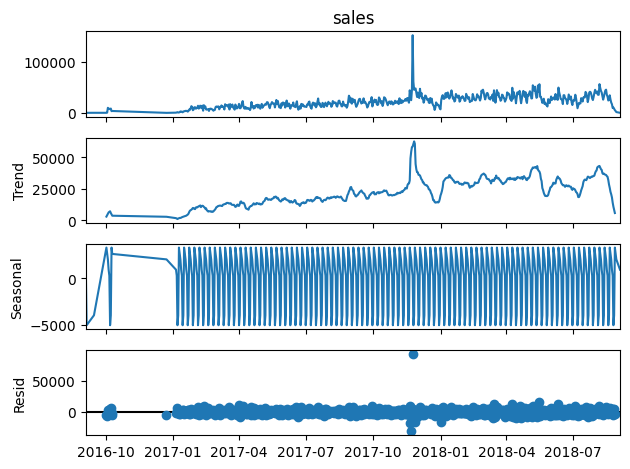

In [5]:
def plot_decomposition(series):
    decomposition = seasonal_decompose(series, model='additive', period=7)
    decomposition.plot()
    plt.show()

plot_decomposition(df_sales['sales'])

3. TRAIN-TEST SPLIT

In [6]:
def train_test_split_ts(df, split=0.8):
    idx = int(len(df)*split)
    return df.iloc[:idx], df.iloc[idx:]

train, test = train_test_split_ts(df_sales)

4. SARIMA MODEL

In [7]:
def fit_sarima(train):
    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    return model.fit()

sarima_model = fit_sarima(train['sales'])

c:\Users\avish\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\avish\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Forecast + Evaluation

c:\Users\avish\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAE: 10468.089669050714
RMSE: 13680.057028973039


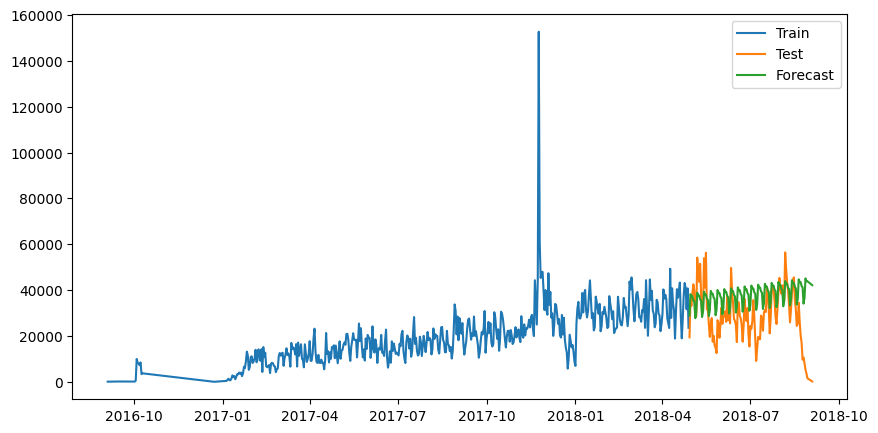

In [8]:
def evaluate_model(model, train, test):
    forecast = model.forecast(len(test))
    
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    
    print("MAE:", mae)
    print("RMSE:", rmse)
    
    plt.figure(figsize=(10,5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(test.index, forecast, label="Forecast")
    plt.legend()
    plt.show()
    
    return forecast

sarima_forecast = evaluate_model(sarima_model, train['sales'], test['sales'])

5. PROPHET MODEL (HIGH SCORE BOOST)

In [9]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


23:18:46 - cmdstanpy - INFO - Chain [1] start processing
23:18:47 - cmdstanpy - INFO - Chain [1] done processing


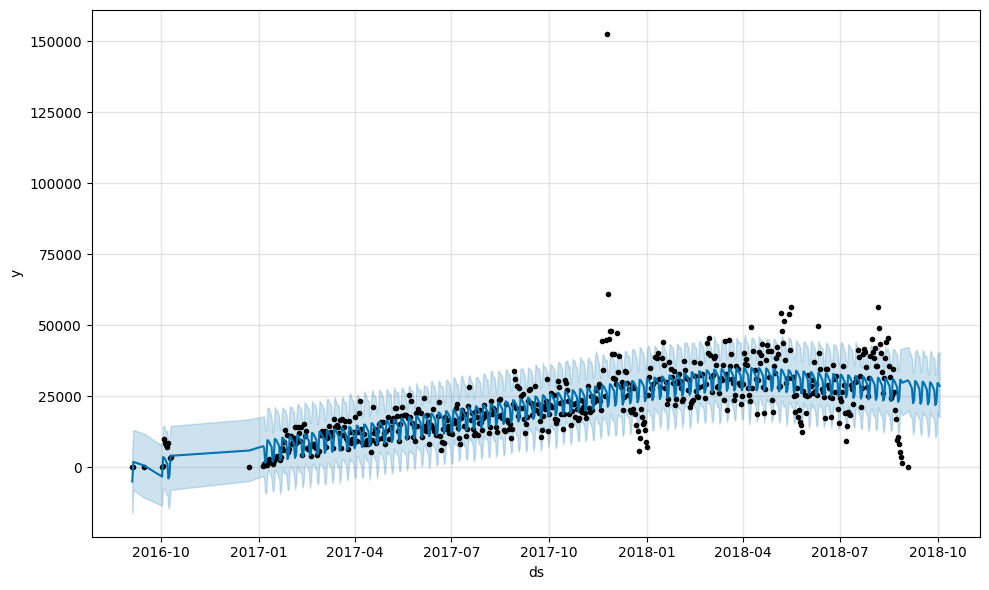

In [10]:
from prophet import Prophet

def run_prophet(df):
    df_p = df.reset_index()
    df_p.columns = ['ds', 'y']
    
    model = Prophet()
    model.fit(df_p)
    
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    
    model.plot(forecast)
    plt.show()
    
    return forecast

prophet_forecast = run_prophet(df_sales)